# آماده‌سازی مجموعه داده

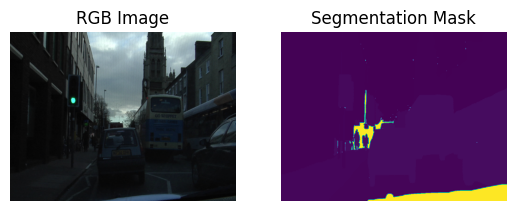

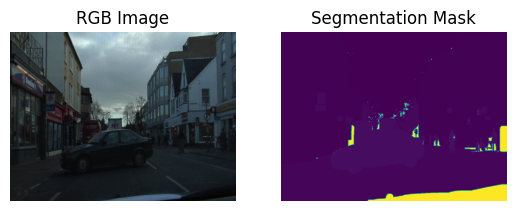

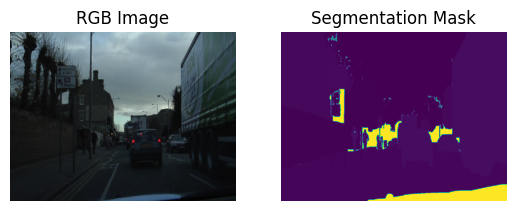

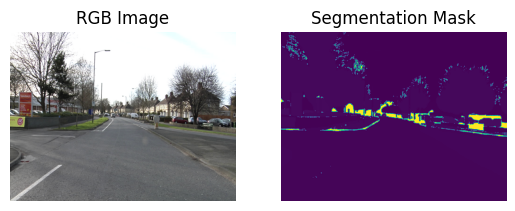

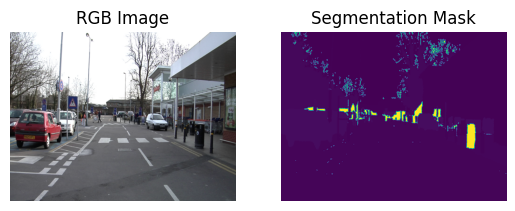

In [1]:
import os
import matplotlib.pyplot as plt 
from PIL import Image

dataset="/kaggle/input/camvid/CamVid-main"
img_dir=os.path.join(dataset,'CamVid_RGB')
mask_dir=os.path.join(dataset,'CamVidGray')

filenames=sorted(os.listdir(img_dir))

for fname in filenames[:250:50]:
    img_path=os.path.join(img_dir,fname)
    mask_path=os.path.join(mask_dir,f"{os.path.splitext(fname)[0]}_L.png")

    img=Image.open(img_path).resize((480,360))  
    mask=Image.open(mask_path).resize((480,360))

    fig,axes=plt.subplots(1,2)
    axes[0].imshow(img)
    axes[0].set_title('RGB Image')
    axes[0].axis('off')
    axes[1].imshow(mask)
    axes[1].set_title('Segmentation Mask')
    axes[1].axis('off')
    plt.show()


In [2]:
split_files={
    'train':'camvid_train.txt',
    'val':'camvid_val.txt',
    'test':'camvid_test.txt'}
counts={}
for split,txt in split_files.items():
    txt_path=os.path.join(dataset,txt)
    with open(txt_path,'r') as f:
        lines=f.readlines()
    counts[split]=len(lines)

print("Dataset split counts:")
for split,cnt in counts.items():
    print(f"{split.title():>4}:{cnt} images")

Dataset split counts:
Train:367 images
 Val:101 images
Test:233 images


# بهینه‌ساز، متریک‌ها و تابع هزینه

In [30]:
import tensorflow as tf

class MeanIoUImplemented(tf.keras.metrics.Metric):
    def __init__(self,num_classes,name="mean_iou",**kwargs):
        super().__init__(name=name,**kwargs)
        self.num_classes = num_classes
        self.conf_matrix = self.add_weight(
            name="confusion_matrix",
            shape=(num_classes, num_classes),
            initializer="zeros",
            dtype=tf.int32)

    def update_state(self,y_true,y_pred,sample_weight=None):
        y_pred_labels=tf.argmax(y_pred,axis=-1,output_type=tf.int32)

        y_true_flat=tf.reshape(y_true,[-1])
        y_pred_flat=tf.reshape(y_pred_labels,[-1])

        batch_cm=tf.math.confusion_matrix(
            labels=y_true_flat,
            predictions=y_pred_flat,
            num_classes=self.num_classes,
            dtype=tf.int32)
        self.conf_matrix.assign_add(batch_cm)

    def result(self):
        cm=tf.cast(self.conf_matrix,tf.float32)
        tp=tf.linalg.tensor_diag_part(cm)
        fp=tf.reduce_sum(cm,axis=0)-tp
        fn=tf.reduce_sum(cm,axis=1)-tp
        denom=tp+fp+fn
        iou=tf.math.divide_no_nan(tp,denom)
        return tf.reduce_mean(iou)

    def reset_states(self):
        tf.keras.backend.batch_set_value(
            [(self.conf_matrix, tf.zeros_like(self.conf_matrix))])


class DiceCoefficientImplemented(tf.keras.metrics.Metric):
    def __init__(self, num_classes,name="dice_coef",smooth=1e-6,**kwargs):
        super().__init__(name=name,**kwargs)
        self.num_classes=num_classes
        self.smooth=smooth
        self.tp=self.add_weight(name="tp",shape=(num_classes,),initializer="zeros",dtype=tf.float32)
        self.fp=self.add_weight(name="fp",shape=(num_classes,),initializer="zeros",dtype=tf.float32)
        self.fn=self.add_weight(name="fn",shape=(num_classes,),initializer="zeros",dtype=tf.float32)

    def update_state(self, y_true, y_pred, sample_weight=None):

        y_pred_labels=tf.argmax(y_pred,axis=-1,output_type=tf.int32)
        y_true_oh=tf.one_hot(y_true,depth=self.num_classes,dtype=tf.float32)
        y_pred_oh=tf.one_hot(y_pred_labels,depth=self.num_classes,dtype=tf.float32)
        axes=[0,1,2]
        tp_batch=tf.reduce_sum(y_true_oh*y_pred_oh,axis=axes)
        fp_batch=tf.reduce_sum((1-y_true_oh)*y_pred_oh,axis=axes)
        fn_batch=tf.reduce_sum(y_true_oh*(1-y_pred_oh),axis=axes)

        self.tp.assign_add(tp_batch)
        self.fp.assign_add(fp_batch)
        self.fn.assign_add(fn_batch)

    def result(self):
        dice=(2.0*self.tp+self.smooth)/(2.0*self.tp+self.fp+self.fn+self.smooth)
        return tf.reduce_mean(dice)

    def reset_states(self):
        for v in (self.tp,self.fp,self.fn):
            v.assign(tf.zeros_like(v))


# پیاده‌سازی مدل

In [31]:

def depthwise_separable_conv(x,filters,stride=2,name=None):
    x=tf.keras.layers.DepthwiseConv2D(
        kernel_size=3,strides=stride,padding='same',
        use_bias=False,name=f'{name}_depthwise')(x)
    x=tf.keras.layers.BatchNormalization(name=f'{name}_depthwise_bn')(x)
    x=tf.keras.layers.ReLU(name=f'{name}_depthwise_relu')(x)
    
    x=tf.keras.layers.Conv2D(
        filters,1,strides=1,padding='same',
        kernel_regularizer=l2_reg,use_bias=False,name=f'{name}_pointwise')(x)
    x=tf.keras.layers.BatchNormalization(name=f'{name}_pointwise_bn')(x)
    x=tf.keras.layers.ReLU(name=f'{name}_pointwise_relu')(x)
    return x

def inverted_residual_block(x,expansion,output_channels,stride,name):
    input_tensor=x
    input_channels=x.shape[-1]
    x_expanded=tf.keras.layers.Conv2D(input_channels*expansion,1,kernel_regularizer=l2_reg,
                                      strides=1,padding='same',use_bias=False,
                                      name=f'{name}_expand')(input_tensor)
    x_expanded=tf.keras.layers.BatchNormalization(name=f'{name}_expand_bn')(x_expanded)
    x_expanded=tf.keras.layers.ReLU(name=f'{name}_expand_relu')(x_expanded)
    
    x=tf.keras.layers.DepthwiseConv2D(3,strides=stride,padding='same', 
                                      use_bias=False,name=f'{name}_depthwise')(x_expanded)
    x=tf.keras.layers.BatchNormalization(name=f'{name}_depthwise_bn')(x)
    x=tf.keras.layers.ReLU(name=f'{name}_depthwise_relu')(x)
    
    x=tf.keras.layers.Conv2D(output_channels,1,strides=1,kernel_regularizer=l2_reg,
                             padding='same',use_bias=False,name=f'{name}_project')(x)
    x=tf.keras.layers.BatchNormalization(name=f'{name}_project_bn')(x)
    
    if stride==1 and input_channels==output_channels:
        x=tf.keras.layers.Add(name=f'{name}_add')([x,input_tensor])
    return x

def pyramid_pooling(x,output_channels,name):
    _,h,w,_=x.shape
    bin_sizes=[1,2,3,6]
    concat_layers=[]
    
    for bin_size in bin_sizes:
        pool=tf.keras.layers.AveragePooling2D(
            (h//bin_size,w//bin_size),strides=(h//bin_size,w//bin_size),padding='valid',
            name=f'{name}_pool_{bin_size}')(x)
        conv=tf.keras.layers.Conv2D(output_channels//4,1,padding='same',
                                    name=f'{name}_conv_{bin_size}')(pool)
        upsample = tf.keras.layers.Lambda(
            lambda z: tf.image.resize(z, (h, w), method='bilinear'),
            name=f'{name}_upsample_{bin_size}'
        )(conv)
        concat_layers.append(upsample)
    
    return tf.keras.layers.Concatenate(axis=-1,name=f'{name}_concat')(concat_layers)

def feature_fusion_module(high_res,low_res,output_channels,name="ffm"):
    low_res_up=tf.keras.layers.UpSampling2D(size=4,interpolation='bilinear',
                                            name=f'{name}_lowres_upsample')(low_res)
    
    low_res_up=tf.keras.layers.DepthwiseConv2D(kernel_size=3,strides=1,dilation_rate=4,
        padding='same',use_bias=False,name=f'{name}_lowres_dwconv')(low_res_up)
    low_res_up=tf.keras.layers.BatchNormalization(name=f'{name}_lowres_bn')(low_res_up)
    low_res_up=tf.keras.layers.ReLU(name=f'{name}_lowres_relu')(low_res_up)
    
    low_res_up=tf.keras.layers.Conv2D(output_channels,kernel_size=1,
                                      kernel_regularizer=l2_reg,
                                      padding='same',use_bias=False,
                                      name=f'{name}_lowres_pwconv')(low_res_up)
    
    high_res=tf.keras.layers.Conv2D(output_channels,kernel_size=1,
                                    kernel_regularizer=l2_reg,
                                    padding='same',use_bias=False,
                                    name=f'{name}_highres_pwconv')(high_res)
    fused=tf.keras.layers.Add(name=f'{name}_add')([high_res,low_res_up])
    fused=tf.keras.layers.ReLU(name=f'{name}_relu')(fused)
    
    return fused



In [32]:
from tensorflow.keras.regularizers import l2

l2_reg=l2(0.00004)

def build_fast_scnn(input_shape=(1024,2048,3),num_classes=12):
    inputs=tf.keras.Input(shape=input_shape)
    
    #Learning to Downsample
    x=tf.keras.layers.Conv2D(32,3,strides=2,padding='same',
                             kernel_regularizer=l2_reg,name='initial_conv')(inputs)
    x=tf.keras.layers.BatchNormalization(name='initial_bn')(x)
    x=tf.keras.layers.ReLU(name='initial_relu')(x)
    
    x=depthwise_separable_conv(x,48,stride=2,name='dsconv1')
    x=depthwise_separable_conv(x,64,stride=2,name='dsconv2')
    high_res_features=x 
    
    #Global Feature Extractor
    x=inverted_residual_block(x,6,64,stride=2,name='gfe_block1')
    x=inverted_residual_block(x,6,64,stride=1,name='gfe_block2')
    x=inverted_residual_block(x,6,64,stride=1,name='gfe_block3')
    x=inverted_residual_block(x,6,96,stride=2,name='gfe_block4')
    x=inverted_residual_block(x,6,96,stride=1,name='gfe_block5')
    x=inverted_residual_block(x,6,96,stride=1,name='gfe_block6')
    x=inverted_residual_block(x,6,128,stride=1,name='gfe_block7')
    x=inverted_residual_block(x,6,128,stride=1,name='gfe_block8')
    x=inverted_residual_block(x,6,128,stride=1,name='gfe_block9')
    low_res_features=pyramid_pooling(x,128,name='PPM')
        
    # Feature Fusion Module
    fused=feature_fusion_module(high_res=high_res_features,low_res=low_res_features,
        output_channels=128,name="feature_fusion")
    
    #Classifier
    x=depthwise_separable_conv(fused,128,name='classifier_dsconv1',stride=1)
    x=depthwise_separable_conv(x,128,name='classifier_dsconv2',stride=1)
    x=tf.keras.layers.Dropout(0.35,name='final_dropout')(x)
    main_output=tf.keras.layers.Conv2D(num_classes,1,
                                       activation='softmax',name='final_conv')(x)
    main_output=tf.keras.layers.UpSampling2D(8,interpolation='bilinear')(main_output)
    
    return tf.keras.Model(inputs=inputs,outputs=main_output,name='Fast-SCNN')

In [33]:
total_epochs=80
model=build_fast_scnn(input_shape=(512,1024,3))
miou=MeanIoUImplemented(num_classes=12)
dice=DiceCoefficientImplemented(num_classes=12)
model.summary()

Model: "Fast-SCNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3             │ (None, 512, 1024, 3)   │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ cast_1 (Cast)             │ (None, 512, 1024, 3)   │              0 │ input_layer_3[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ initial_conv (Conv2D)     │ (None, 256, 512, 32)   │            896 │ cast_1[0][0]           │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ initial_bn                │ (None, 256, 512, 32)   │            128 │ initial_conv[0][0]     │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ initial_relu (ReLU)       │ (None, 256, 512, 32)   │              0 │ initial_bn[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dsconv1_depthwise         │ (None, 128, 256, 32)   │            288 │ initial_relu[0][0]     │
│ (DepthwiseConv2D)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dsconv1_depthwise_bn      │ (None, 128, 256, 32)   │            128 │ dsconv1_depthwise[0][… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dsconv1_depthwise_relu    │ (None, 128, 256, 32)   │              0 │ dsconv1_depthwise_bn[… │
│ (ReLU)                    │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dsconv1_pointwise         │ (None, 128, 256, 48)   │          1,536 │ dsconv1_depthwise_rel… │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dsconv1_pointwise_bn      │ (None, 128, 256, 48)   │            192 │ dsconv1_pointwise[0][… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dsconv1_pointwise_relu    │ (None, 128, 256, 48)   │              0 │ dsconv1_pointwise_bn[… │
│ (ReLU)                    │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dsconv2_depthwise         │ (None, 64, 128, 48)    │            432 │ dsconv1_pointwise_rel… │
│ (DepthwiseConv2D)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dsconv2_depthwise_bn      │ (None, 64, 128, 48)    │            192 │ dsconv2_depthwise[0][… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dsconv2_depthwise_relu    │ (None, 64, 128, 48)    │              0 │ dsconv2_depthwise_bn[… │
│ (ReLU)                    │                        │                │                        │
├──────────────────────

 Total params: 1,125,916 (4.30 MB)

 Trainable params: 1,103,260 (4.21 MB)

 Non-trainable params: 22,656 (88.50 KB)

# آموزش مدل

In [34]:
base_dir="/kaggle/input/camvid/CamVid-main"
AUTOTUNE=tf.data.AUTOTUNE
def read_split(txt_fname):
    img_paths,msk_paths=[],[]
    split_path=os.path.join(base_dir,txt_fname)
    with open(split_path,'r') as f:
        for line in f.read().splitlines():
            img_rel,msk_rel=line.split()
            img_paths.append(os.path.join(base_dir,img_rel))
            msk_paths.append(os.path.join(base_dir,msk_rel))
    return img_paths,msk_paths



IMG_SIZE=(512,1024)

def preprocess_pair(img_path,mask_path):
    img=tf.io.read_file(img_path)
    img=tf.image.decode_png(img,channels=3)
    img=tf.image.resize(img,IMG_SIZE)
    img=tf.cast(img,tf.float32)/255.0

    m=tf.io.read_file(mask_path)
    m=tf.image.decode_png(m,channels=1,dtype=tf.uint8)
    m=tf.image.resize(m,IMG_SIZE,method='nearest')
    m=tf.cast(m,tf.uint8)
    m=tf.squeeze(m,axis=-1)
    m=tf.cast(m,tf.int32)
    return img,m

train_paths,train_masks=read_split('camvid_train.txt')
val_paths,val_masks=read_split('camvid_val.txt')
test_paths,test_masks=read_split('camvid_test.txt')

def remap_labels(x,y):
    y=tf.where(y==255,11,y)
    return x, y

train_ds=(
    tf.data.Dataset.from_tensor_slices((train_paths,train_masks))
    .map(preprocess_pair,num_parallel_calls=AUTOTUNE)
    .map(remap_labels)
    .batch(6)
    .prefetch(AUTOTUNE))

val_ds=(
    tf.data.Dataset.from_tensor_slices((val_paths,val_masks))
    .map(preprocess_pair,num_parallel_calls=AUTOTUNE)
    .map(remap_labels)
    .batch(6)
    .prefetch(AUTOTUNE))

test_ds=(
    tf.data.Dataset.from_tensor_slices((test_paths,test_masks))
    .map(preprocess_pair,num_parallel_calls=AUTOTUNE)
    .map(remap_labels)   
    .batch(6)
    .prefetch(AUTOTUNE))

In [35]:
from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy('mixed_float16')

In [40]:
NUM_CLASSES=12
def dice_loss(y_true,y_pred,smooth=1e-6):
    y_true_onehot=tf.one_hot(tf.cast(y_true,tf.int32),depth=12) 
    y_true_onehot=tf.reshape(y_true_onehot,shape=tf.shape(y_pred))
    
    intersection=tf.reduce_sum(y_true_onehot*y_pred,axis=[1,2])
    union=tf.reduce_sum(y_true_onehot+y_pred,axis=[1,2])
    dice=(2.*intersection+smooth)/(union+smooth)
    return 1-tf.reduce_mean(dice)

def combo_loss(y_true,y_pred,alpha=0.4):
    ce=tf.keras.losses.sparse_categorical_crossentropy(y_true,y_pred)
    dice=dice_loss(y_true,y_pred)
    return alpha*ce+(1-alpha)*dice
with tf.device('/device:GPU:0'):
    miou=MeanIoUImplemented(num_classes=NUM_CLASSES)
    dice=DiceCoefficientImplemented(num_classes=NUM_CLASSES)

lr_scheduler=tf.keras.callbacks.ReduceLROnPlateau(monitor='val_mean_iou',
                                                  factor=0.6,patience=12,min_lr=1e-5)


model.compile(
    optimizer=tf.keras.optimizers.AdamW(learning_rate=0.004,weight_decay=1e-4),
    loss=combo_loss,
    metrics=['accuracy',miou,dice],
    jit_compile=False)


In [41]:
history=model.fit(
    train_ds,
    epochs=total_epochs+20,
    batch_size=32,
    validation_data=val_ds,
    callbacks=[lr_scheduler])

Epoch 1/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 62s 372ms/step - accuracy: 0.8953 - dice_coef: 0.7297 - loss: 0.4402 - mean_iou: 0.6081 - val_accuracy: 0.0976 - val_dice_coef: 0.0210 - val_loss: 6.4324 - val_mean_iou: 0.0117 - learning_rate: 0.0040
Epoch 2/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 21s 341ms/step - accuracy: 0.8424 - dice_coef: 0.6325 - loss: 0.5634 - mean_iou: 0.5024 - val_accuracy: 0.1360 - val_dice_coef: 0.0426 - val_loss: 6.0864 - val_mean_iou: 0.0236 - learning_rate: 0.0040
Epoch 3/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 22s 346ms/step - accuracy: 0.8543 - dice_coef: 0.6540 - loss: 0.5348 - mean_iou: 0.5245 - val_accuracy: 0.4305 - val_dice_coef: 0.2503 - val_loss: 2.1590 - val_mean_iou: 0.1653 - learning_rate: 0.0040
Epoch 4/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 21s 337ms/step - accuracy: 0.8826 - dice_coef: 0.7140 - loss: 0.4693 - mean_iou: 0.5886 - val_accuracy: 0.7712 - val_dice_coef: 0.4822 - val_loss: 0.8503 - val_mean_iou: 0.3838 - learning_rate: 0.0040
Epoch 5/100
62/62 ━━━━━━━━━━━━━━━━━━━━ 2

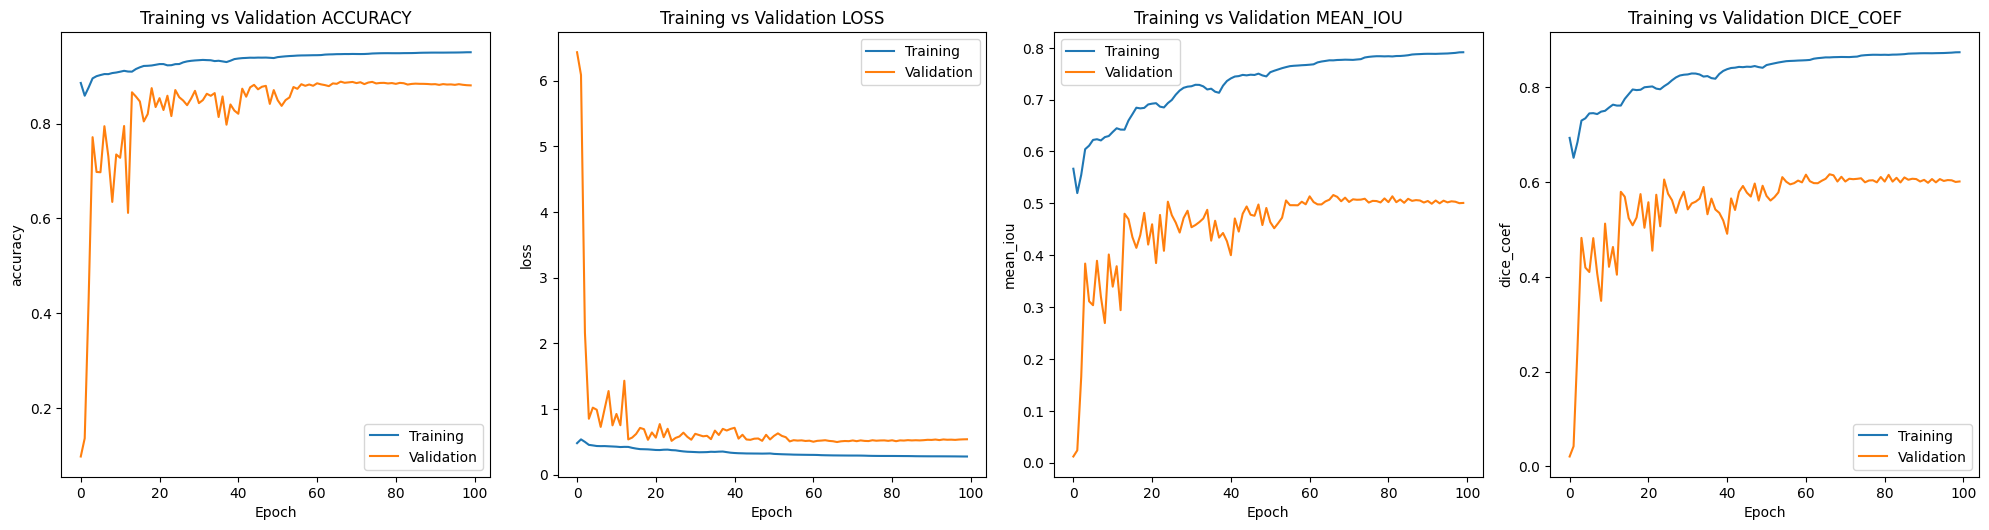

In [55]:
import matplotlib.pyplot as plt

def plot_metrics(history,metric_names):
    plt.figure(figsize=(20,10))
    for i, metric in enumerate(metric_names,1):
        plt.subplot(2,4,i)
        plt.plot(history.history[metric],label='Training')
        plt.plot(history.history[f'val_{metric}'],label='Validation')
        plt.title(f'Training vs Validation {metric.upper()}')
        plt.xlabel('Epoch')
        plt.ylabel(metric)
        plt.legend()
    plt.tight_layout()
    plt.show()

plot_metrics(history, ['accuracy','loss','mean_iou','dice_coef'])

# ارزیابی مدل

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


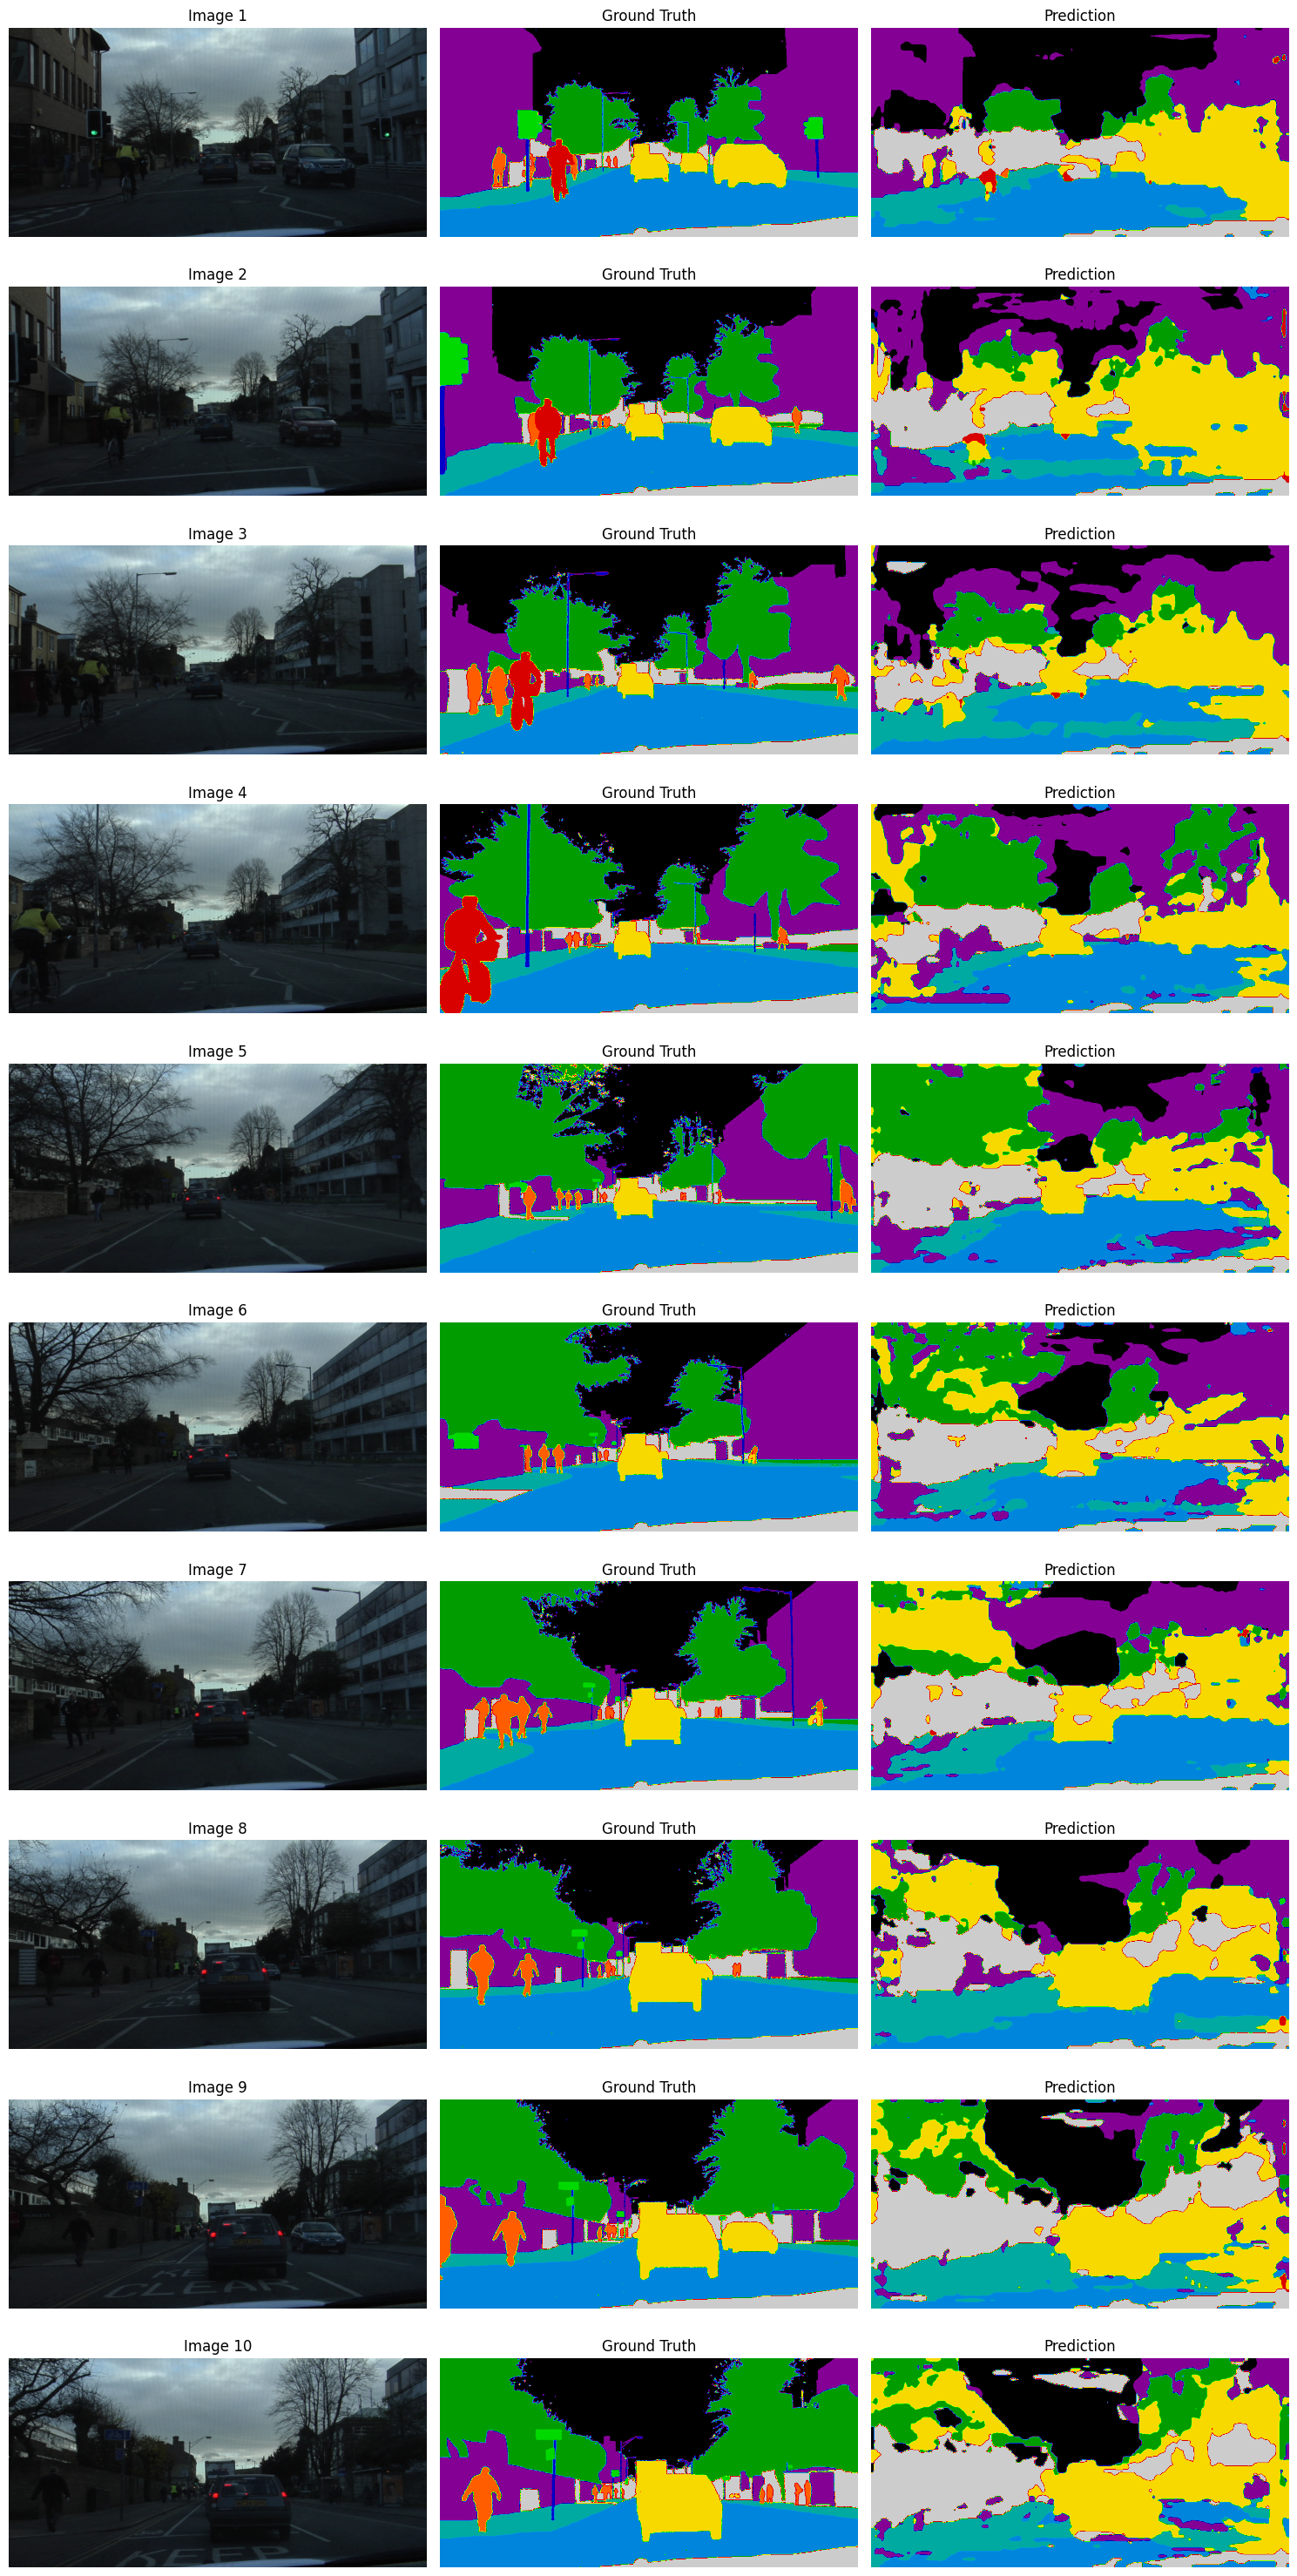

In [68]:
test_unbatched=test_ds.unbatch()

sample_ds=test_unbatched.take(10)
imgs=[]
masks=[]
for img,m in sample_ds:
    imgs.append(img)
    masks.append(m)
imgs=tf.stack(imgs)    
masks=tf.stack(masks)     
preds=model.predict(imgs)
pred_labels=tf.argmax(preds,axis=-1)

plt.figure(figsize=(15,30))
for i in range(10):
    vis_img=(imgs[i].numpy()*255).astype("uint8")

    plt.subplot(10,3,3*i+1)
    plt.imshow(vis_img)
    plt.title(f"Image {i+1}")
    plt.axis("off")

    plt.subplot(10,3,3*i+2)
    plt.imshow(masks[i].numpy(),cmap="nipy_spectral",vmin=0,vmax=11)
    plt.title("Ground Truth")
    plt.axis("off")

    plt.subplot(10,3,3*i+3)
    plt.imshow(pred_labels[i].numpy(),cmap="nipy_spectral",vmin=0,vmax=11)
    plt.title("Prediction")
    plt.axis("off")

plt.tight_layout()
plt.show()
